In [3]:
from rdkit import Chem
from rdkit.Chem import rdDetermineBonds
import numpy as np
import pandas as pd 
from scipy.spatial.transform import Rotation as R
from scipy.spatial.distance import pdist, squareform
from pathlib import Path 
import tqdm
import umap
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib.patches as mpatches
import hdbscan
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from pydiffmap import diffusion_map as dm


In [4]:
def xyz_to_rdkit_mol(xyz_file, total_charge):
    """
    Convert an XYZ file with explicit hydrogens to an RDKit Mol,
    preserving 3D coordinates and determining connectivity automatically.
    

    Parameters:
        xyz_file: path to XYZ file
        total_charge: total molecular charge (default 0)
    
    Returns:
        RDKit Mol object
    """
    # --- Read XYZ ---
    with open(xyz_file) as f:
        lines = f.readlines()[2:]  # skip atom count + comment
    atoms, coords = [], []

    for line in lines:
        parts = line.split()
        atoms.append(parts[0])
        coords.append([float(x) for x in parts[1:4]])
    coords = np.array(coords)
    
    # --- Create empty molecule with atoms ---
    mol = Chem.RWMol()
    z = [Chem.GetPeriodicTable().GetAtomicNumber(a) for a in atoms]
    for Zi in z:
        mol.AddAtom(Chem.Atom(Zi))
    
    # --- Add coordinates ---
    conf = Chem.Conformer(len(coords))
    for i, pos in enumerate(coords):
        conf.SetAtomPosition(i, pos)
    mol.AddConformer(conf)
    
    # --- Determine connectivity using RDKit's bond perception ---
    Chem.rdDetermineBonds.DetermineConnectivity(mol, charge=total_charge)
    
    # --- Sanitize molecule ---
    Chem.SanitizeMol(mol)
    
    return mol

def numpy_geom(mol):
    conf = mol.GetConformer()
    return np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])


In [5]:
raw_spawns_folder = Path('../../../data/aligned_geometries/SeamStress/benzene/type2/spawn')
mecis = [ 
   Path('../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type1.xyz'),
    Path('../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type2.xyz'),
    Path('../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type3.xyz'),
    
]


In [6]:
idx = []
geometries = []

smiles = []

for x in tqdm.tqdm(list(raw_spawns_folder.glob('*'))):
    mol = xyz_to_rdkit_mol(x,total_charge=0)
    smile = Chem.MolToSmiles(mol, canonical=True)
    geom = numpy_geom(mol)
    flattend_geom = geom.flatten()
    geometries.append(flattend_geom)
    idx.append(x.stem)
    smiles.append(smile)


for meci in mecis:
    print(meci)
    mol = xyz_to_rdkit_mol(meci,total_charge=0)
    smile = Chem.MolToSmiles(mol, canonical=True)

    geom = numpy_geom(mol)
    flattend_geom = geom.flatten()
    geometries.append(flattend_geom)
    smiles.append(smile)
    idx.append(meci.stem)

feature_vector = np.array(geometries)







100%|██████████| 1190/1190 [00:05<00:00, 207.54it/s]

../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type1.xyz
../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type2.xyz
../../../data/aligned_geometries/SeamStress/benzene/type2/meci/Type3.xyz


In [9]:
reduction_technique = "UMAP"
reducer  = umap.UMAP(random_state=42,n_components=2).fit(feature_vector)
reduced_space = reducer.transform(feature_vector)

/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/homebrew/anaconda3/envs/conf-align/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


/var/folders/_9/20wjp7894bs7kfh3bml0zbw40000gn/T/ipykernel_79774/181232953.py:106: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


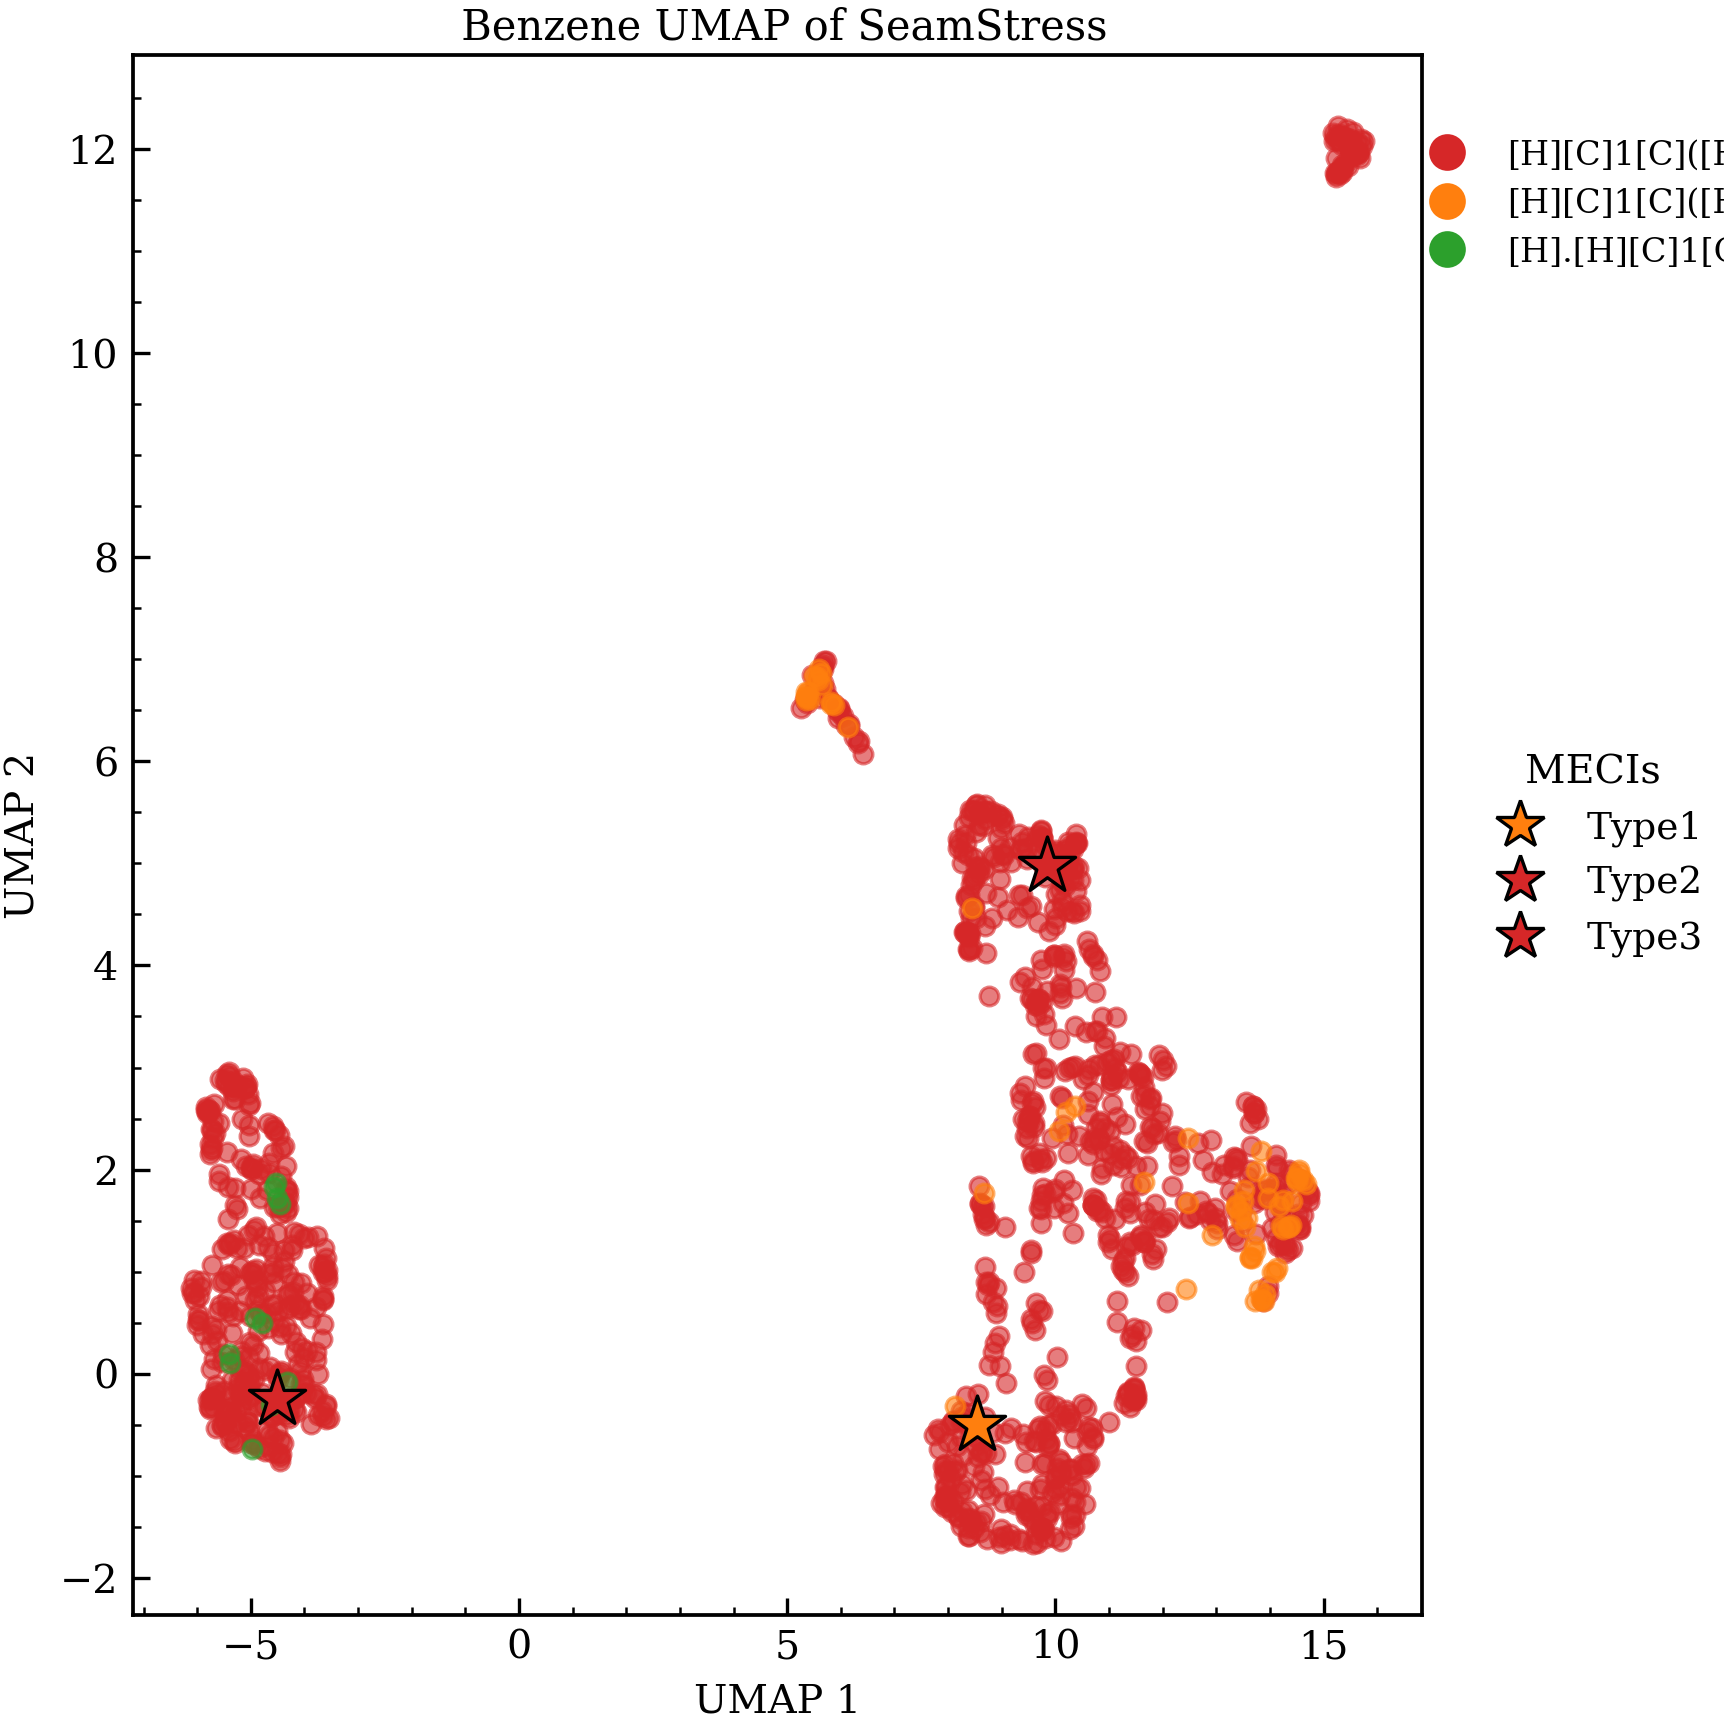

In [8]:


n_spawns = len(list(raw_spawns_folder.glob('*')))

X_spawns = reduced_space[:n_spawns]
X_mecis  = reduced_space[n_spawns:]

smiles_spawns = smiles[:n_spawns]
smiles_mecis  = smiles[n_spawns:]
idx_mecis     = idx[n_spawns:]

unique_smiles = list(dict.fromkeys(smiles))

plt.style.use("/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/prl.mplstyle")


color_list = [
    "tab:red",
    "tab:orange",
    "tab:green",
    "tab:blue",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]

if len(unique_smiles) > len(color_list):
    raise ValueError("Not enough colors for number of unique SMILES")

smiles_to_color = {
    smi: color_list[i]
    for i, smi in enumerate(unique_smiles)
}

fig, ax = plt.subplots(figsize=(6, 6))

for smi in unique_smiles:
    mask = [s == smi for s in smiles_spawns]
    ax.scatter(
        X_spawns[mask, 0],
        X_spawns[mask, 1],
        color=smiles_to_color[smi],
        s=20,
        alpha=0.6
    )

for (x, y), smi in zip(X_mecis, smiles_mecis):
    ax.scatter(
        x, y,
        marker="*",
        s=200,
        color=smiles_to_color[smi],
        edgecolor="k",
        linewidth=0.8
    )


smiles_handles = [
    plt.Line2D(
        [], [],
        marker='o',
        linestyle='',
        color=smiles_to_color[smi],
        label=smi,
        markersize=8
    )
    for smi in unique_smiles
]

legend_smiles = ax.legend(
    handles=smiles_handles,
    title="SMILES",
    loc="upper left",
    bbox_to_anchor=(0.97, 1),
    fontsize=8
)
ax.add_artist(legend_smiles)


meci_handles = [
    plt.Line2D(
        [], [],
        marker='*',
        linestyle='',
        color=smiles_to_color[smi],
        markeredgecolor='k',
        markeredgewidth=0.8,
        label=name,
        markersize=12
    )
    for name, smi in zip(idx_mecis, smiles_mecis)
]

ax.legend(
    handles=meci_handles,
    title="MECIs",
    loc="lower left",
    bbox_to_anchor=(1.02, 0.4)
)

ax.set_xlabel(f"{reduction_technique} 1")
ax.set_ylabel(f"{reduction_technique} 2")
ax.set_title(f" Benzene {reduction_technique} of SeamStress")

plt.tight_layout()
plt.show()


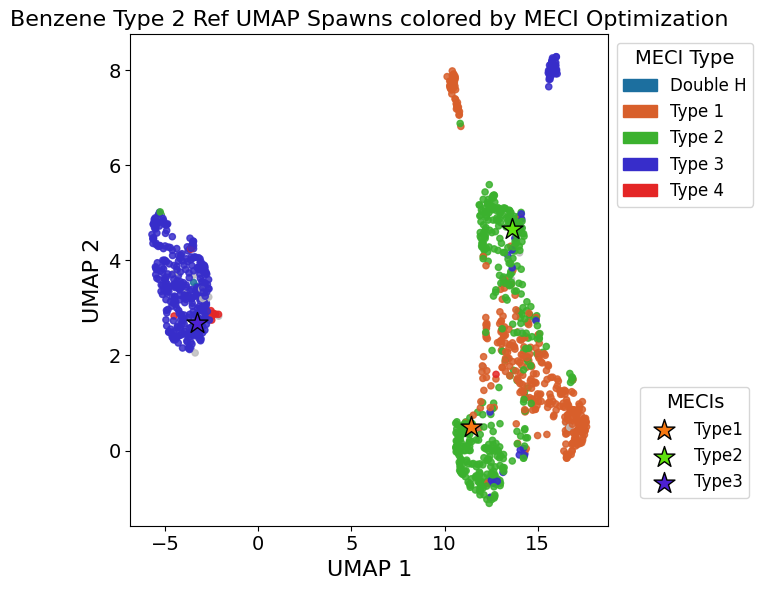

In [12]:


csv_file = "../../../data/meci_classification/benzene/S1S0/meci_labels_humanlabels.csv"
n_star = len(mecis)
star_size = 250
point_size = 20

base_colors = ["#1c6f9f", "#d85f2b", "#3bb12e", "#372dca", "#e42626", "#800080", "#00ced1", "#15bad4", "#60ca97", "#1a45bb"]
star_edgecolor = "black"

df = pd.read_csv(csv_file)

meci_idx_to_type = dict(zip(df['idx'], df['meci_type']))

unique_types = sorted(df['meci_type'].unique())
type_to_color = {t: base_colors[i % len(base_colors)] for i, t in enumerate(unique_types)}

point_types = [meci_idx_to_type.get(i, "Unknown") for i in idx]
point_colors = [type_to_color.get(t, "#bdbdbd") for t in point_types]


star_colors_dict = {
    idx[-4]: "#0075f3",  
    idx[-3]: "#f57812", 
    idx[-2]: "#60e30e",  
    idx[-1]: "#4d21d2", 

}

plt.figure(figsize=(7,6))
plt.scatter(reduced_space[:,0], reduced_space[:,1], c=point_colors, s=point_size, alpha=0.85)

star_indices = np.arange(len(reduced_space) - n_star, len(reduced_space))
star_handles = []
for star_idx in star_indices:
    star_color = star_colors_dict.get(idx[star_idx], point_colors[star_idx])
    h = plt.scatter(
        reduced_space[star_idx,0],
        reduced_space[star_idx,1],
        marker="*",
        s=star_size,
        color=star_color,
        edgecolor=star_edgecolor,
        linewidth=1.0,
        zorder=10,
        label=str(idx[star_idx])
    )
    star_handles.append(h)

type_patches = [mpatches.Patch(color=color, label=t) for t, color in type_to_color.items()]
type_legend = plt.legend(handles=type_patches, title="MECI Type", bbox_to_anchor=(1.0, 1),
                         loc="upper left", title_fontsize=14, fontsize=12)
plt.gca().add_artist(type_legend)

star_legend = plt.legend(handles=star_handles, title="MECIs", bbox_to_anchor=(1.05, 0.3),
                        loc="upper left", title_fontsize=14, fontsize=12)

plt.xlabel(f"{reduction_technique} 1", fontsize=16)
plt.ylabel(f"{reduction_technique} 2", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f"Benzene Type 2 Ref {reduction_technique} Spawns colored by MECI Optimization", fontsize=16)
plt.grid(False)
plt.tight_layout()
plt.show()


In [15]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# --- Load labels ---
df = pd.read_csv(csv_file)
meci_idx_to_type = dict(zip(df['idx'], df['meci_type']))

unique_types = sorted(df['meci_type'].unique())
type_to_color = {t: base_colors[i % len(base_colors)] for i, t in enumerate(unique_types)}

# --- Point metadata ---
point_types = [meci_idx_to_type.get(i, "Unknown") for i in idx]
point_colors = [type_to_color.get(t, "#bdbdbd") for t in point_types]

# --- Regular points trace ---
scatter = go.Scatter(
    x=reduced_space[:, 0],
    y=reduced_space[:, 1],
    mode="markers",
    marker=dict(
        size=10,
        color=point_colors,
        opacity=0.85
    ),
    text=[
        f"idx: {i}<br>MECI type: {t}"
        for i, t in zip(idx, point_types)
    ],
    hoverinfo="text",
    showlegend=False
)

# --- Star points ---
star_indices = np.arange(len(reduced_space) - n_star, len(reduced_space))
star_traces = []


# --- MECI type legend (dummy traces for legend only) ---
type_legend_traces = [
    go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(size=10, color=color),
        legendgroup=t,
        showlegend=True,
        name=t
    )
    for t, color in type_to_color.items()
]

# --- Build figure ---
fig = go.Figure(
    data=[scatter] + star_traces + type_legend_traces
)

fig.update_layout(
    width=700,
    height=600,
    title=f"Benzene Type 2 Ref {reduction_technique} Spawns colored by MECI Optimization",
    xaxis_title=f"{reduction_technique} 1",
    yaxis_title=f"{reduction_technique} 2",
    legend_title_text="Legend",
    template="simple_white",
    hovermode="closest"
)

fig.show()


In [22]:
# --- Define 2D start/end ---
start_2d = np.array([11.895, -0.6732])
end_2d   = np.array([12.6069, 4.8782])

num_points = 50
series_pts_2d = np.linspace(start_2d, end_2d, num_points)

# --- 2D series trace with UMAP hover ---
series_trace = go.Scatter(
    x=series_pts_2d[:, 0],
    y=series_pts_2d[:, 1],
    mode="lines+markers",
    line=dict(color="black", width=2),
    marker=dict(size=6, symbol="circle"),
    name="2D interpolation path",
    hoverinfo="text",
    text=[
        f"UMAP 1: {x:.4f}<br>UMAP 2: {y:.4f}"
        for x, y in series_pts_2d
    ]
)

# --- Regular points trace with UMAP coordinates in hover ---
scatter = go.Scatter(
    x=reduced_space[:, 0],
    y=reduced_space[:, 1],
    mode="markers",
    marker=dict(
        size=10,
        color=point_colors,
        opacity=0.85
    ),
    hoverinfo="text",
    text=[
        (
            f"idx: {i}<br>"
            f"MECI type: {t}<br>"
            f"UMAP 1: {x:.4f}<br>"
            f"UMAP 2: {y:.4f}"
        )
        for i, t, x, y in zip(
            idx,
            point_types,
            reduced_space[:, 0],
            reduced_space[:, 1]
        )
    ],
    showlegend=False
)

# --- New figure with series ---
fig_series = go.Figure(
    data=[scatter] + star_traces + [series_trace] + type_legend_traces
)

fig_series.update_layout(
    width=700,
    height=600,
    title=f"Benzene Type 2 Ref {reduction_technique} + 2D Series",
    xaxis_title=f"{reduction_technique} 1",
    yaxis_title=f"{reduction_technique} 2",
    legend_title_text="Legend",
    template="simple_white",
    hovermode="closest"
)

fig_series.show()


In [25]:
# --- Inverse UMAP: 2D → original space (XYZ) ---
reconstructed_xyz = reducer.inverse_transform(series_pts_2d)

print(reconstructed_xyz.shape)

atom_types = ["C", "C", "C", "C", "C", "C", "H", "H", "H", "H", "H", "H"]  # example
n_atoms = len(atom_types)


(50, 36)


In [ ]:
# --- Write XYZ trajectory ---
xyz_file = "/Users/connerbaucom/Desktop/Pieri/CTG/dim_red_comp/PhotoStats/notebooks/algorithm_classification/benzene/umap_series_trajectory1.xyz"

with open(xyz_file, "w") as f:
    for i, geom in enumerate(reconstructed_xyz):

        geom = np.asarray(geom)

        # --- FIX: reshape if flat ---
        if geom.ndim == 1:
            if geom.size != n_atoms * 3:
                raise ValueError(
                    f"Frame {i}: expected {n_atoms*3} values, got {geom.size}"
                )
            geom = geom.reshape(n_atoms, 3)

        f.write(f"{n_atoms}\n")
        f.write(f"UMAP-inverse frame {i}\n")

        for atom, (x, y, z) in zip(atom_types, geom):
            f.write(f"{atom} {x:.6f} {y:.6f} {z:.6f}\n")

print(f"XYZ trajectory written to: {xyz_file}")


TypeError: cannot unpack non-iterable numpy.float32 object